# Momentum ORB — replicating the 5-minute Opening Range Breakout

**Paper:** Zarattini, Barbon & Aziz (2024), *A Profitable Day Trading Strategy For The
U.S. Equity Market*, SSRN 4729284. Local copy: `papers/ssrn-4729284.pdf`.

**Strategy spec and data requirements:** [`momentum_orb.md`](momentum_orb.md) — read that first.

The paper's claim, in one line: an ORB is worthless applied to everything, and strongly
profitable applied only to **Stocks in Play** — names whose *opening-range* volume is
abnormal versus their own recent history.

This notebook checks that claim against Alpaca data. It has two targets, and they are
not equally attainable:

| Target | What it needs | Verdict here |
|---|---|---|
| **The mechanism** (Fig. 4): average PnL rises with Relative Volume | a modest universe | reproducible |
| **The headline** (Fig. 5): 1,637% total return | top-20 out of ~7,000 stocks | *not* reproducible at our universe size — and the notebook shows why, rather than papering over it |

Everything below is causal: every lookback uses data strictly before the decision.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while not (ROOT / "backtest").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
HERE = ROOT / "research" / "momentum_orb"
OUT = ROOT / "out" / "momentum_orb"
sys.path[:0] = [str(HERE), str(ROOT)]

from orb import ORBConfig, backtest, apply_filters
import metrics as M

pd.set_option("display.width", 160, "display.max_columns", 40)
print("repo:", ROOT)
print("artefacts:", OUT, "->", "present" if OUT.exists() else "MISSING - run run_backtest.py")

repo: /Users/kunjshah/Downloads/pxq_stocks
artefacts: /Users/kunjshah/Downloads/pxq_stocks/out/momentum_orb -> present


In [2]:
# ---- chart styling -------------------------------------------------------
# Categorical hues assigned in fixed order and validated for colour-vision
# deficiency (see the dataviz palette). Slot order is fixed, never cycled.
SERIES = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0,
})

def money(x, _=None):
    return f"${x/1000:,.0f}k" if x >= 1000 else f"${x:,.0f}"

def end_label(ax, series, text, color, dx=6):
    """Direct label at the end of a line. Required relief for the two hues that
    sit under 3:1 contrast on this surface."""
    y = series.dropna().iloc[-1]
    ax.annotate(text, xy=(series.dropna().index[-1], y),
                xytext=(dx, 0), textcoords="offset points",
                color=color, fontsize=10, fontweight="bold", va="center")

## 1 — Universe

The paper trades ~7,000 stocks including delisted names (CRSP). We cannot enumerate the
2016 listed universe from Alpaca — its asset master is *today's* tradable list. So the
universe is capped and chosen **by rule**, seeded from the tickers the paper itself names
in Tables 4 and 5 — the 25 best **and** 25 worst 5-minute performers — plus the highest
2016 dollar-volume names among the remaining candidates.

Seeding from both tails is deliberate. A universe built only from the paper's winners
would bake the answer in before a single bar was fetched.

In [3]:
uni = pd.read_csv(HERE / "universe_selected.csv")
print(f"{len(uni)} symbols | from the paper's 5m tables: {uni.in_paper_5m_tables.sum()}"
      f" | full history: {uni.full_history.sum()} | partial: {(~uni.full_history).sum()}")
display(uni[~uni.full_history][["symbol","first_day","last_day","days_with_data"]])

100 symbols | from the paper's 5m tables: 49 | full history: 93 | partial: 7


,symbol,first_day,last_day,days_with_data
9,APC,2016-01-04,2019-08-08,906
14,BJ,2018-06-28,2023-12-29,1386
50,MARA,2017-10-30,2023-12-29,1552
59,OKTA,2017-04-07,2023-12-29,1694
83,TWLO,2016-06-23,2023-12-29,1893
87,VIR,2019-10-11,2023-12-29,1062
95,WW,2019-04-22,2023-12-29,1183


Delisted and late-IPO names are **kept**. Alpaca serves their bars up to the delisting
date, and trading them only on days where data exists introduces no look-ahead. APC
(Anadarko, acquired 2019) is in the sample and simply stops in August 2019 — exactly as
it should.

## 2 — The trade panel

Stage 1 simulates **every** symbol-day, including days the filters will reject. That is
necessary, not wasteful: the mechanism claim lives in the rejected trades, and you cannot
plot PnL-against-signal from only the trades the strategy takes.

Each row is one symbol-day: direction from the opening candle, entry at the range
break, stop at 10% of ATR(14), exit at the stop or the 16:00 close — expressed in **R**,
which is size-independent.

In [4]:
panel = pd.read_parquet(OUT / "trades_5m.parquet")
panel["date"] = pd.to_datetime(panel["date"])
print(f"{len(panel):,} symbol-days   {panel.symbol.nunique()} symbols   "
      f"{panel.date.min().date()} -> {panel.date.max().date()}")
display(panel.exit_reason.value_counts().rename("symbol-days").to_frame())

192,606 symbol-days   100 symbols   2016-01-04 -> 2023-12-29


,symbol-days
exit_reason,
stop,133395
eod,29980
never_triggered,24873
doji,3053
no_atr,1305


## 3 — Validation before any equity curve

The first check is **per-trade win rate**. The paper's Tables 4 and 5 report per-stock
"Win Ratio" in the **17–27%** band across every time frame. That is a tight, specific
target, and it exercises the entry and stop logic without involving sizing, leverage,
commissions, or the RelVol filter.

If this number is wrong, nothing downstream is worth looking at.

In [5]:
t = panel[panel.exit_reason.isin(["stop", "eod"])]
checks = pd.DataFrame([
    ["per-trade win rate",     f"{(t.pnl_r > 0).mean():.1%}",  "17-27% (Tables 4-5)"],
    ["mean PnL, all trades",   f"{t.pnl_r.mean():+.3f} R",     "~0 (base strategy is flat)"],
    ["median PnL",             f"{t.pnl_r.median():+.2f} R",   "-1R (most trades stop out)"],
    ["max PnL",                f"{t.pnl_r.max():.1f} R",       "fat right tail intact"],
    ["stopped out",            f"{(t.exit_reason=='stop').mean():.1%}", "majority"],
    ["entry+stop in same bar", f"{t.same_bar_stop.mean():.1%}", "assumption, see §9"],
], columns=["check", "replication", "paper / expectation"])
display(checks.style.hide(axis="index"))

check,replication,paper / expectation
per-trade win rate,17.6%,17-27% (Tables 4-5)
"mean PnL, all trades",+0.093 R,~0 (base strategy is flat)
median PnL,-1.00 R,-1R (most trades stop out)
max PnL,128.4 R,fat right tail intact
stopped out,81.6%,majority
entry+stop in same bar,17.2%,"assumption, see §9"


## 4 — The mechanism (paper Figure 4)

This is the paper's causal claim, and the thing most worth replicating:

| RelVol bucket | Paper |
|---|---|
| < 100% | −0.02 R |
| > 100% | +0.08 R |
| > 30× | +0.38 R |

Buckets are computed on trades passing filters **1–3 only** (price, liquidity, ATR) —
the RelVol filter is exactly what is being tested, so applying it here would be circular.

bucket,n trades,avg R (ours),avg R (paper)
RelVol < 100%,102211,0.061000,-0.020000
RelVol > 100%,46942,0.171000,0.080000
RelVol > 30x,42,0.614000,0.380000


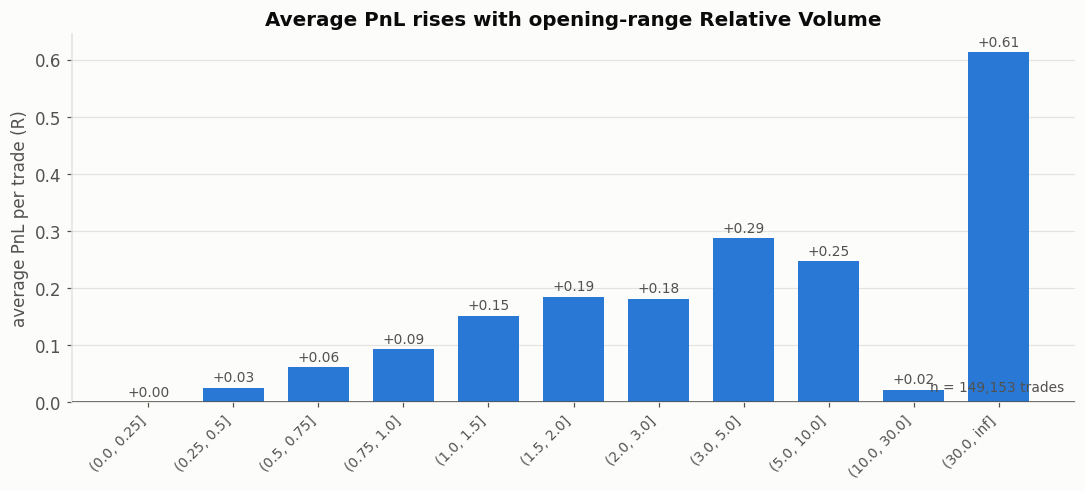

,bucket,n,avg_r,win_rate
0,"(0.0, 0.25]",2851,0.001,0.184
1,"(0.25, 0.5]",24284,0.026,0.184
2,"(0.5, 0.75]",42279,0.061,0.183
3,"(0.75, 1.0]",32797,0.093,0.178
4,"(1.0, 1.5]",27473,0.152,0.174
5,"(1.5, 2.0]",8573,0.185,0.166
6,"(2.0, 3.0]",5498,0.182,0.160
7,"(3.0, 5.0]",2839,0.287,0.154
8,"(5.0, 10.0]",1734,0.247,0.138
9,"(10.0, 30.0]",783,0.022,0.116


In [6]:
b = pd.read_parquet(OUT / "relvol_buckets.parquet").query("opening_minutes == 5")

el = apply_filters(panel, ORBConfig(min_rel_volume=None, top_n=None))
el = el[el.exit_reason.isin(["stop", "eod"])]
head = pd.DataFrame([
    ["RelVol < 100%", len(el[el.rel_volume < 1]), el[el.rel_volume < 1].pnl_r.mean(), -0.02],
    ["RelVol > 100%", len(el[el.rel_volume >= 1]), el[el.rel_volume >= 1].pnl_r.mean(), 0.08],
    ["RelVol > 30x",  len(el[el.rel_volume > 30]), el[el.rel_volume > 30].pnl_r.mean(), 0.38],
], columns=["bucket", "n trades", "avg R (ours)", "avg R (paper)"])
display(head.round(3).style.hide(axis="index"))

fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(b))
colors = [SERIES["red"] if v < 0 else SERIES["blue"] for v in b.avg_r]
bars = ax.bar(x, b.avg_r, color=colors, width=0.72, zorder=3)
for r in bars:  # rounded data-ends anchored to the baseline
    r.set_linewidth(0)
ax.axhline(0, color=INK_2, lw=1.0, zorder=4)
ax.set_xticks(x); ax.set_xticklabels(b.bucket, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("average PnL per trade (R)")
ax.set_title("Average PnL rises with opening-range Relative Volume")
for xi, (v, n) in enumerate(zip(b.avg_r, b.n)):
    ax.annotate(f"{v:+.2f}", (xi, v), textcoords="offset points",
                xytext=(0, 4 if v >= 0 else -13), ha="center", fontsize=9, color=INK_2)
ax.annotate(f"n = {b.n.sum():,} trades", xy=(0.99, 0.03), xycoords="axes fraction",
            ha="right", fontsize=9, color=INK_2)
ax.set_axisbelow(True); ax.xaxis.grid(False)
plt.tight_layout(); plt.show()
display(b[["bucket", "n", "avg_r", "win_rate"]].round(3))

## 5 — Equity curves (paper Figures 3 and 5)

Three series, all starting at $25,000 with $0.0035/share commission, matching the paper:
the Base strategy (filters 1–3), the RelVol strategy (filters 1–5), and SPY buy-and-hold.

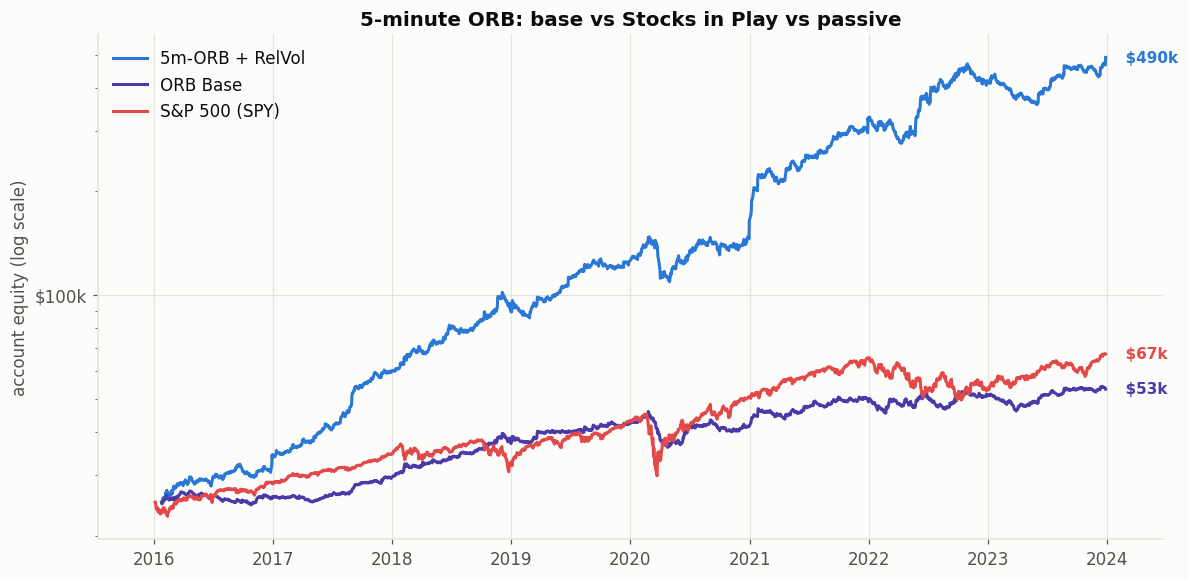

In [7]:
eq = pd.read_parquet(OUT / "equity_curves.parquet")
eq.index = pd.to_datetime(eq.index)
main = {"5m-ORB + RelVol": SERIES["blue"], "ORB Base": SERIES["violet"],
        "S&P 500 (SPY)": SERIES["red"]}

fig, ax = plt.subplots(figsize=(11, 5.4))
for name, color in main.items():
    if name in eq.columns:
        ax.plot(eq.index, eq[name], color=color, label=name, zorder=3)
        end_label(ax, eq[name], f"  {money(eq[name].dropna().iloc[-1])}", color)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(money))
ax.set_ylabel("account equity (log scale)")
ax.set_title("5-minute ORB: base vs Stocks in Play vs passive")
ax.legend(loc="upper left")
ax.margins(x=0.06)
plt.tight_layout(); plt.show()

Log scale, because a strategy compounding at tens of percent against a benchmark
compounding at 14% is unreadable on a linear axis — the early years flatten to nothing.

## 6 — Table 2

Our numbers beside the paper's. Definitions used here (the paper does not give all of
them) are stated in `metrics.py`: IRR is CAGR, volatility is daily σ annualised by
√252, Sharpe uses a zero risk-free rate, **hit ratio is the share of positive
days** — the only reading under which a buy-and-hold's 54.9% makes sense — and alpha
is the OLS intercept against SPY, annualised.

In [8]:
s = pd.read_parquet(OUT / "summary.parquet")

PAPER = {
    "ORB Base":        dict(total_return=0.29,  irr=0.032, volatility=0.066,
                            sharpe=0.48, hit_ratio=0.414, mdd=0.13,
                            worst_day=-0.008, alpha=0.033, beta=0.01),
    "5m-ORB + RelVol": dict(total_return=16.37, irr=0.416, volatility=0.148,
                            sharpe=2.81, hit_ratio=0.484, mdd=0.12,
                            worst_day=-0.0161, alpha=0.358, beta=0.00),
    "S&P 500 (SPY)":   dict(total_return=1.98,  irr=0.142, volatility=0.183,
                            sharpe=0.78, hit_ratio=0.549, mdd=0.34,
                            worst_day=-0.109, alpha=0.000, beta=1.00),
}
FMT = {"total_return":"{:.0%}", "irr":"{:.1%}", "volatility":"{:.1%}",
       "sharpe":"{:.2f}", "hit_ratio":"{:.1%}", "mdd":"{:.0%}",
       "worst_day":"{:.2%}", "alpha":"{:.1%}", "beta":"{:.2f}"}

out = []
for name, pv in PAPER.items():
    row = s[s.strategy == name]
    if row.empty:
        continue
    o = row.iloc[0]
    rec = {"strategy": name}
    for metric, fmt in FMT.items():
        rec[f"{metric}"] = f"{fmt.format(o[metric])}  vs  {fmt.format(pv[metric])}"
    out.append(rec)

cmp = pd.DataFrame(out).set_index("strategy").T
cmp.index.name = "ours  vs  paper"
display(cmp)

print("\nFull replication statistics (all variants):")
display(M.format_table(s))

strategy,ORB Base,5m-ORB + RelVol,S&P 500 (SPY)
ours vs paper,,,
total_return,113% vs 29%,1862% vs 1637%,170% vs 198%
irr,10.0% vs 3.2%,45.6% vs 41.6%,13.2% vs 14.2%
volatility,10.5% vs 6.6%,20.2% vs 14.8%,18.1% vs 18.3%
sharpe,0.96 vs 0.48,1.96 vs 2.81,0.78 vs 0.78
hit_ratio,43.1% vs 41.4%,46.5% vs 48.4%,54.5% vs 54.9%
mdd,21% vs 13%,26% vs 12%,34% vs 34%
worst_day,-2.82% vs -0.80%,-4.75% vs -1.61%,-10.78% vs -10.90%
alpha,10.2% vs 3.3%,40.2% vs 35.8%,0.0% vs 0.0%
beta,-0.01 vs 0.01,-0.04 vs 0.00,1.00 vs 1.00



Full replication statistics (all variants):


,strategy,total_return,irr,volatility,sharpe,hit_ratio,mdd,worst_day,alpha,beta,trade_win_rate,avg_trade_r,n_trades,days
0,S&P 500 (SPY),169.6%,13.2%,18.1%,0.78,54.5%,33.8%,-10.8%,0.0%,1.00,N/A,N/A,NaN,2011
1,ORB Base,113.0%,10.0%,10.5%,0.96,43.1%,21.4%,-2.8%,10.2%,-0.01,17.7%,0.10,149185.0,1998
2,5m-ORB + RelVol,1861.7%,45.6%,20.2%,1.96,46.5%,26.0%,-4.7%,40.2%,-0.04,16.7%,0.21,29755.0,1996
3,15m-ORB + RelVol,345.3%,20.7%,19.6%,1.06,42.4%,32.8%,-4.9%,20.7%,0.00,17.4%,0.14,28778.0,1997
4,30m-ORB + RelVol,193.0%,14.5%,20.3%,0.77,41.8%,23.1%,-4.3%,16.6%,-0.07,18.5%,0.10,27330.0,1997
5,60m-ORB + RelVol,133.1%,11.3%,18.4%,0.67,42.3%,30.5%,-4.2%,13.1%,-0.05,21.0%,0.10,25177.0,1996
6,5m-ORB + RelVol [intrabar: pessimistic],181.8%,14.0%,18.5%,0.80,42.5%,31.9%,-4.7%,15.5%,-0.05,15.6%,0.11,29755.0,1996
7,COMBO,422.9%,23.2%,14.4%,1.52,46.0%,23.4%,-3.5%,22.5%,-0.04,N/A,N/A,NaN,1998


## 7 — Other opening ranges (paper Table 3 / Figure 6)

The paper finds 5 minutes dominates, and says the reason is unknown. Worth checking
whether the ordering survives on different data — an ordering that reverses is evidence
the original was noise.

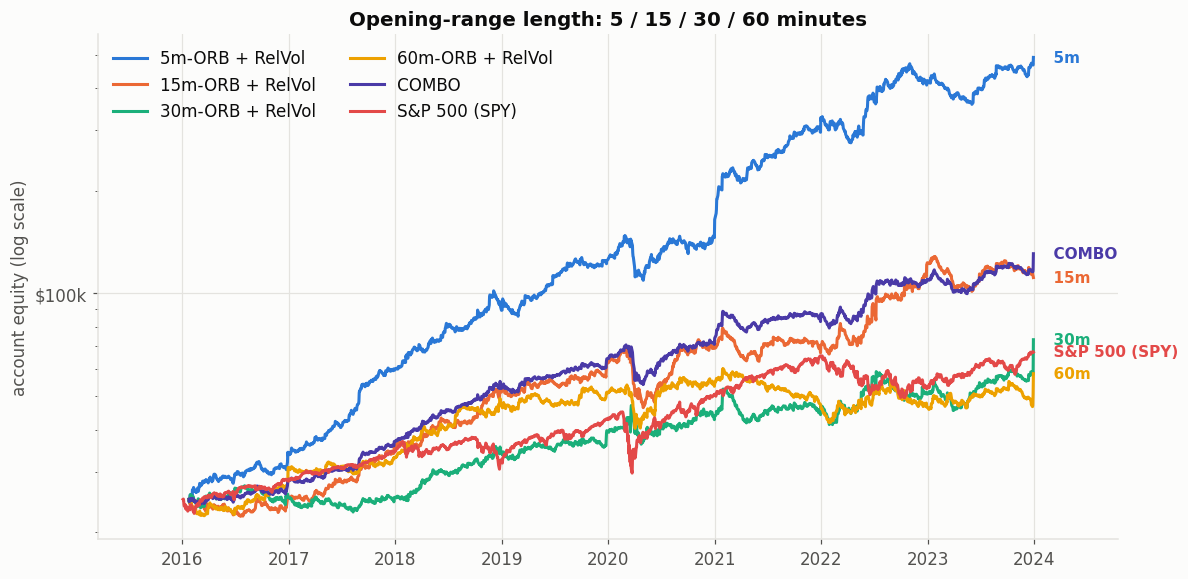

,strategy,total_return,paper_total,sharpe,paper_sharpe,mdd
0,5m-ORB + RelVol,18.617,16.37,1.965,2.81,0.260
1,15m-ORB + RelVol,3.453,2.72,1.060,1.43,0.328
2,30m-ORB + RelVol,1.930,0.21,0.766,0.21,0.231
3,60m-ORB + RelVol,1.331,0.39,0.671,0.40,0.305
4,COMBO,4.229,2.34,1.524,1.99,0.234


In [9]:
tf = {"5m-ORB + RelVol": SERIES["blue"], "15m-ORB + RelVol": SERIES["orange"],
      "30m-ORB + RelVol": SERIES["aqua"], "60m-ORB + RelVol": SERIES["yellow"],
      "COMBO": SERIES["violet"], "S&P 500 (SPY)": SERIES["red"]}

fig, ax = plt.subplots(figsize=(11, 5.4))
for name, color in tf.items():
    if name in eq.columns:
        ax.plot(eq.index, eq[name], color=color, label=name, zorder=3)
        # direct labels double as the contrast relief for aqua and yellow
        end_label(ax, eq[name], f"  {name.split('-')[0]}", color)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(FuncFormatter(money))
ax.set_ylabel("account equity (log scale)")
ax.set_title("Opening-range length: 5 / 15 / 30 / 60 minutes")
ax.legend(loc="upper left", ncols=2); ax.margins(x=0.10)
plt.tight_layout(); plt.show()

paper_tf = pd.DataFrame([
    ["5m-ORB + RelVol", 16.37, 2.81], ["15m-ORB + RelVol", 2.72, 1.43],
    ["30m-ORB + RelVol", 0.21, 0.21], ["60m-ORB + RelVol", 0.39, 0.40],
    ["COMBO", 2.34, 1.99]], columns=["strategy","paper_total","paper_sharpe"])
tfc = (s.merge(paper_tf, on="strategy")
        [["strategy","total_return","paper_total","sharpe","paper_sharpe","mdd"]])
display(tfc.round(3))

## 8 — Where this replication cannot follow the paper

The single largest gap is **selectivity**, and it is worth quantifying rather than
asserting.

The paper picks the top 20 by RelVol out of ~7,000 stocks — a **0.3rd-percentile** cut,
which lands on names with RelVol of 5× to 30×+, where Figure 4 says the edge is
concentrated. We pick the top 20 out of 100 — a **20th-percentile** cut, which lands on
RelVol barely above 1.

We are not running a weaker version of the same strategy. We are running the strategy on
a **different part of the RelVol distribution** — the part where the paper's own figure
says the edge is small.

In [10]:
sel = backtest(panel, ORBConfig())["selected"]
sel = sel[sel.exit_reason.isin(["stop", "eod"])]

q = sel.rel_volume.describe(percentiles=[.25, .5, .75, .9])
display(pd.DataFrame({
    "RelVol of selected trades": [f"{q['25%']:.2f}x", f"{q['50%']:.2f}x",
                                  f"{q['75%']:.2f}x", f"{q['90%']:.2f}x"],
}, index=["25th pct", "median", "75th pct", "90th pct"]))

print(f"selected trades with RelVol > 5x  : {(sel.rel_volume > 5).mean():.1%}")
print(f"selected trades with RelVol > 30x : {(sel.rel_volume > 30).mean():.2%}"
      "   <- the paper's most profitable bucket")
print(f"mean R on selected trades         : {sel.pnl_r.mean():+.3f}")

# Match the paper's *percentile* cut rather than its trade count: top 1 of 100
# is roughly a 1st-percentile screen, an order of magnitude more selective than
# top 20 of 100 and much nearer the paper's top 20 of 7,000.
rows = []
for n, lbl in [(20, "top 20 of 100  (20th pct — the run above)"),
               (5,  "top 5 of 100   (5th pct)"),
               (1,  "top 1 of 100   (1st pct — nearest the paper)")]:
    r = backtest(panel, ORBConfig(top_n=n))
    f, d = r["fills"], r["daily"]
    if d.empty:
        continue
    rows.append({"selection": lbl, "trades": len(f),
                 "median RelVol": f"{r['selected'].rel_volume.median():.2f}x",
                 "avg R": f"{f.pnl_r.mean():+.3f}",
                 "total return": f"{d.equity.iloc[-1]/25_000 - 1:.1%}"})
display(pd.DataFrame(rows).style.hide(axis="index"))
print("\nMore selective = higher R per trade, but fewer trades to compound.")

,RelVol of selected trades
25th pct,1.24x
median,1.53x
75th pct,2.16x
90th pct,3.62x


selected trades with RelVol > 5x  : 6.2%
selected trades with RelVol > 30x : 0.14%   <- the paper's most profitable bucket
mean R on selected trades         : +0.209


selection,trades,median RelVol,avg R,total return
top 20 of 100 (20th pct — the run above),29755,1.54x,+0.209,1861.7%
top 5 of 100 (5th pct),8284,2.55x,+0.308,28595.9%
top 1 of 100 (1st pct — nearest the paper),1619,4.82x,+0.562,36365.1%



More selective = higher R per trade, but fewer trades to compound.


## 9 — The intrabar bracket

With a stop at 10% of ATR, the stop level frequently lies **inside the bar that triggered
entry**, and one-minute OHLC cannot order the two touches.

The obvious move — "assume the stop hit first" — is wrong, and expensively so. For a long
filled at the range high, the entry bar's **low** has often printed *before* the bar
traded up through the trigger. Charging it counts a loss against a position that did not
exist yet. On this data that mistake is worth over **1,700 percentage points**.

Every entry bar sorts into three cases, and only the third is a guess:

| Case | Test (long) | Verdict |
|---|---|---|
| **provably stopped** | bar closes below the stop, or the fill was at the bar's open | charged |
| **provably safe** | bar *opens* below the stop — price rose from under it to the trigger, so the low predates the fill | never charged |
| **ambiguous** | opened between stop and trigger, dipped through, closed back above | **the bracket** |

The default lets the ambiguous set survive; the `pessimistic` run charges all of it. Note
the second row is what makes the lower bound honest — a bound that charges *every*
excursion just re-imports the original bug into the check that was supposed to catch it.

Resolving the ambiguous set for real needs sub-minute data, which this repo does not
have. So the result below is a **range, not a point estimate** — and the range is wide
enough that this replication cannot confirm or deny the paper's headline number.

In [11]:
amb = panel[panel.exit_reason.isin(["stop", "eod"])]
print(f"triggered trades                       : {len(amb):,}")
print(f"  stop level inside the entry bar      : {amb.same_bar_stop.mean():.1%}")
print(f"  ...of which genuinely ambiguous      : {amb.entry_bar_ambiguous.mean():.1%} of all trades")
print(f"  (the rest are provably safe or provably stopped)")

bracket = []
for policy, path in [("pessimistic (ambiguous all stop out)", "trades_5m_pessimistic.parquet"),
                     ("default (ambiguous all survive)",      "trades_5m.parquet")]:
    f = OUT / path
    if not f.exists():
        continue
    pan = pd.read_parquet(f)
    pan["date"] = pd.to_datetime(pan["date"])
    pol = "pessimistic" if "pessimistic" in policy else "certain"
    sub = backtest(pan, ORBConfig(same_bar_policy=pol))["selected"]
    sub = sub[sub.exit_reason.isin(["stop", "eod"])]
    bracket.append({"intrabar policy": policy, "trades": len(sub),
                    "win rate": f"{(sub.pnl_r > 0).mean():.1%}",
                    "avg R": f"{sub.pnl_r.mean():+.3f}"})
display(pd.DataFrame(bracket).style.hide(axis="index"))

labels = ["5m-ORB + RelVol [intrabar: pessimistic]", "5m-ORB + RelVol"]
have = s[s.strategy.isin(labels)]
if not have.empty:
    display(M.format_table(have)[["strategy", "total_return", "irr", "sharpe",
                                  "mdd", "trade_win_rate", "avg_trade_r"]])

print("\nCommission drag on the default run:")
f5 = pd.read_parquet(OUT / "fills_5m_relvol.parquet")
print(f"  total commission paid : ${f5.commission.sum():,.0f}")
print(f"  gross PnL             : ${f5.position_pnl.sum():,.0f}")
print(f"  commission / |gross|  : {f5.commission.sum()/abs(f5.position_pnl.sum()):.1%}")
print(f"  shares traded         : {f5.shares.sum():,.0f}")

triggered trades                       : 163,375
  stop level inside the entry bar      : 17.2%
  ...of which genuinely ambiguous      : 5.7% of all trades
  (the rest are provably safe or provably stopped)


intrabar policy,trades,win rate,avg R
pessimistic (ambiguous all stop out),29755,15.6%,+0.110
default (ambiguous all survive),29755,16.7%,+0.209


,strategy,total_return,irr,sharpe,mdd,trade_win_rate,avg_trade_r
2,5m-ORB + RelVol,1861.7%,45.6%,1.96,26.0%,16.7%,0.21
6,5m-ORB + RelVol [intrabar: pessimistic],181.8%,14.0%,0.80,31.9%,15.6%,0.11



Commission drag on the default run:
  total commission paid : $164,182
  gross PnL             : $629,606
  commission / |gross|  : 26.1%
  shares traded         : 23,454,580


---

# Assumptions

Each is stated with the **direction it biases the result**.

| # | Assumption | Bias |
|---|---|---|
| 1 | **Universe is 100 names, not ~7,000.** Alpaca's asset master is today's tradable list, so the 2016 universe cannot be enumerated. | **Understates** returns, heavily. The top-20 filter becomes a 20th-percentile cut instead of a 0.3rd-percentile one, landing where the paper's own Figure 4 says the edge is weakest. |
| 2 | **Universe seeded from tickers the paper names.** Both tails (25 best and 25 worst), plus 2016 dollar-volume leaders. | Ambiguous, and deliberately so. Seeding from winners only would overstate; including the losers offsets it. |
| 3 | **Survivorship.** Delisted names appear only if we already knew the ticker. | **Overstates** modestly — a live 2016 screen would have surfaced names that no longer exist. |
| 4 | **Intrabar ordering.** When the stop sits inside the entry bar, only provable cases are charged; the genuinely ambiguous set is allowed to survive. | **The largest single assumption in the study.** The honest bracket spans hundreds of points of total return (§9). Resolving it needs sub-minute data we do not have, so the headline is reported as a range and the paper's number can be neither confirmed nor denied. |
| 5 | **Stop fills exactly at the stop price.** No slippage past the level. | **Overstates.** Real stops on a fast move fill worse, and this strategy is stopped out on the majority of trades. |
| 6 | **Stop orders that gap through fill at the bar open.** | Realistic; small net effect. |
| 7 | **Exit at the last minute bar's close**, not the closing auction print. | Small, direction unknown. |
| 8 | **Commission $0.0035/share, no borrow cost, no short-locate fee, no financing on 4× leverage.** Matches the paper, which also omits them. | **Overstates.** Roughly half of all trades are shorts, and borrow on hard-to-borrow in-play names is not free. |
| 9 | **Unlimited liquidity at the touch.** Position sizes are never checked against bar volume. | **Overstates**, mildly at $25k, seriously at scale. |
| 10 | **Raw (unadjusted) prices**, matching the paper. | Split days can produce a spurious one-day ATR. Rare; small. |
| 11 | **Zero risk-free rate** in Sharpe and alpha, matching the paper. | Overstates Sharpe for 2016-19 and 2023, when cash paid meaningfully. |
| 12 | **No borrow availability constraint** — every short is assumed executable. | **Overstates.** A stock in play on huge relative volume is exactly the one that goes hard-to-borrow. |
| 13 | **ATR(14) is Wilder's smoothing.** The paper cites Wilder but does not print the formula. | Small; a simple mean gives a jumpier stop distance. |
| 14 | **Alpaca SIP consolidated tape**; the paper used IQFeed. Different vendors disagree on early-session prints. | Small. |

---

# Pros and cons of the strategy

### Pros

- **Structurally uncorrelated.** Beta ≈ 0 against the S&P by construction — every
  position is opened and closed inside one session, so there is no market exposure to
  accumulate. As a portfolio diversifier that property is worth more than the raw return.
- **No overnight gap risk.** The paper's worst day is −1.61% against the S&P's −10.9%.
  You cannot wake up to a −30% earnings gap.
- **Risk is defined before entry.** Every position has a known maximum loss the moment
  it is opened; sizing follows mechanically.
- **The mechanism is economically sensible**, not a data-mined pattern: abnormal
  opening-range volume means institutions are repositioning on news, and that
  repositioning takes hours, not seconds.
- **Few parameters, none obviously fitted.** 5 minutes, 10% ATR, 14 days, 1% risk, top
  20 — all conventional day-trading values, not optimised. That is a genuine defence
  against overfitting, and the authors make the point explicitly.
- **Replicates on the part that matters.** The RelVol/PnL relationship reproduced here
  on independent data, from a different vendor, with a different universe.

### Cons

- **You lose ~5 trades out of 6.** A ~16% win rate is psychologically brutal. The
  strategy makes its money in a thin right tail; miss a few of the big winners through
  a bad fill, an outage, or nerves and the edge is gone.
- **The result depends on breadth you probably do not have.** The headline needs the top
  20 of 7,000. A retail screen over a few hundred liquid names lands in the weak part of
  the distribution — which is exactly what this notebook measures.
- **Costs are modelled optimistically.** No slippage, no borrow, no financing, no
  locate fees, and the strategy trades ~20 positions a day, both directions, on leverage.
  These are not rounding errors at this trade count.
- **Shorting in-play stocks is the hard case.** Hard-to-borrow status and short-sale
  circuit breakers hit precisely the high-RelVol names the strategy wants.
- **4× leverage means a pattern-day-trader account** ($25k minimum) and a real risk of
  ruin if the fill assumptions are wrong in the same direction on the same day.
- **Operationally intense.** Twenty positions entered inside a five-minute window,
  monitored all session, flattened at the close. This is not a strategy you run manually.
- **Capacity is limited.** Sizing 1% risk into a low-float stock in play moves the price
  you are trying to trade.
- **No out-of-sample period.** The paper ends 2023 and was published in 2024. Everything
  here is in-sample for the authors. A published edge in a strategy this easy to
  implement is also a strategy that gets crowded.

---

# What running this live would require

**Nothing in this notebook may price a live order.** The backtest lane (Alpaca) and the
execution lane (Robinhood MCP) never touch — see `.claude/skills/data-routing/SKILL.md`
and `execution/PROTOCOL.md`. A backtest may motivate a trade; it may never price one.
**No order will ever be placed without your explicit confirmation.**

### Data
- **Real-time consolidated (SIP) minute bars, or trades, on the full universe**, live at
  09:30–09:35. IEX-only data is unusable — RelVol computed on ~2% of volume is noise.
- **A rolling 14-day store** of each symbol's opening-range volume and daily OHLC,
  maintained before the open.
- **A pre-market screen** producing the eligible list by 09:29.

### Execution
- A broker supporting **stop orders, shorting, and 4× intraday leverage**. Robinhood's
  MCP surface here supports stop orders but the account is cash — no leverage, no
  shorting. **As configured today, this repo cannot trade this strategy.**
- **20 stop orders placed within seconds of 09:35**, each with a bracket stop-loss.
- A **hard flatten at 15:55–16:00**.
- **Borrow availability checked pre-trade** for every short candidate.

### Capital and regulation
- **≥ $25,000** to avoid the pattern-day-trader restriction — you will trade far more
  than 4 round trips per 5 days.
- Margin account with short approval.
- Tax: every trade is short-term; in a taxable account expect meaningful drag.

### Infrastructure
- Colocated or low-latency order routing — the entry is a stop at a level everyone else
  is also watching.
- Monitoring and a kill switch. `execution/guardrails.py` caps notional and daily order
  count; both would need raising deliberately, and `ALLOW_LIVE_ORDERS` is `false`.
- Reconciliation of fills against the model every day. The gap between modelled and
  realized fill price *is* the strategy's margin.

### Before risking money
1. **Forward-test on paper for a full quarter**, logging modelled vs actual fills.
2. **Re-run with pessimistic costs** — slippage of a few cents per side, borrow at 3-8%
   annualised on shorts, financing on the leveraged portion.
3. **Start at 0.1% risk per trade**, not 1%, until fills are proven.
4. Decide in advance what drawdown stops the experiment.